# Exploratory Data Analysis

- Added all necessary imports
- Loaded the cleaned data
- Added the clean data as a dataframe to the variable social_media_data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED_DIR = "../data/processed/"

# Creating function to load data from the processed directory
def load_data(filename="social_cleaned.csv"):
    df = pd.read_csv(
        os.path.join(PROCESSED_DIR, filename),
        encoding="latin-1"
    )
    return df

social_media_data = load_data()


# Understanding the data
Since the data has already been cleaned, there is no need to do any cleaning here.

In [2]:
# Firs five rows of the data
social_media_data.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,addiction_level_numeric
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443,2
1,16,Female,Usa,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864,3
2,25,Female,India,2.782420,Tiktok,2,Socializing,18.170204,1,6.035397,Medium,62.524625,2
3,27,Male,India,3.486598,Youtube,4,Education,22.493804,1,8.110861,Medium,31.935102,2
4,23,Female,India,3.748829,Tiktok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046,2


In [3]:
# Number of rows and columns
print("Rows: ", social_media_data.shape[0])
print("Columns: ", social_media_data.shape[1])

Rows:  1000000
Columns:  13


In [4]:
# Data types of each column
print(social_media_data.dtypes)

age                           int64
gender                          str
country                         str
daily_usage_hours           float64
primary_platform                str
num_platforms_used            int64
purpose                         str
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level                 str
screen_time_before_sleep    float64
addiction_level_numeric       int64
dtype: object


# Plotting Column Distributions

<Axes: ylabel='Frequency'>

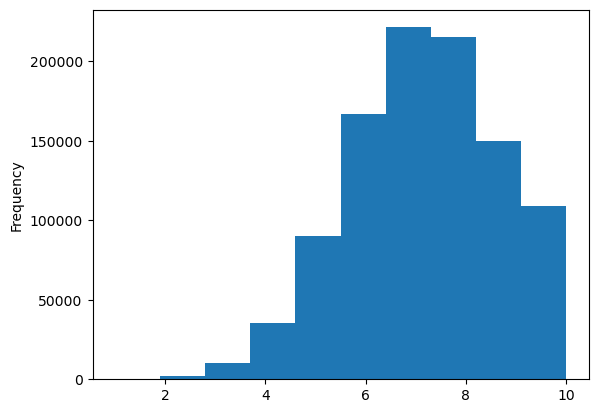

In [5]:
# Mental Health Score
social_media_data['mental_health_score'].plot(kind='hist')

<Axes: ylabel='Frequency'>

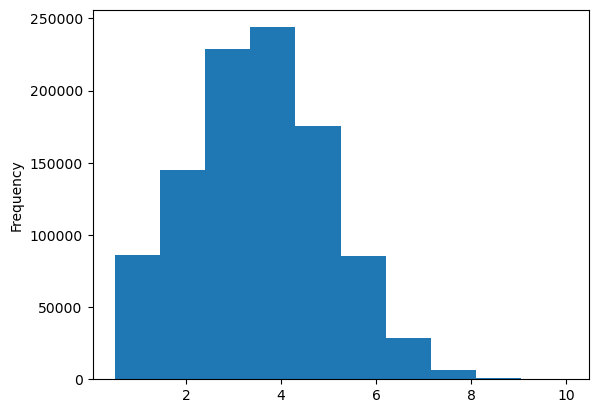

In [6]:
# Daily usage hours
social_media_data['daily_usage_hours'].plot(kind='hist')

<Axes: ylabel='Frequency'>

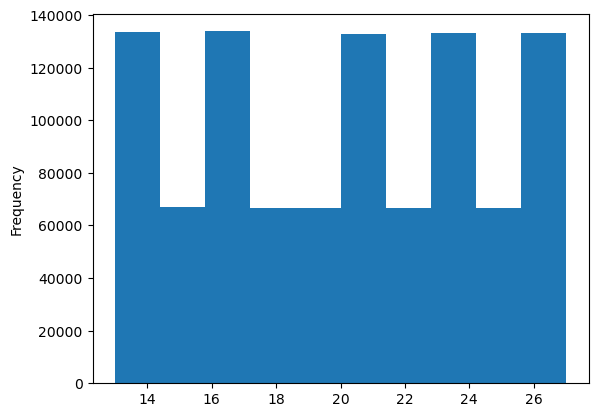

In [7]:
# Age
social_media_data['age'].plot(kind='hist')

# Breakdowns
- Mental health score by gender
- Mental health score by country
- Mental health score by purpose

The goal of these breakdowns is ot determine how country, gender, and purporse correlate with an individuals mental health score. 

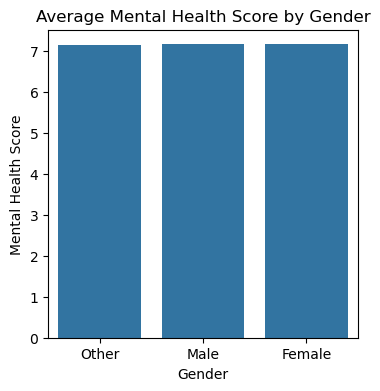

In [8]:
# Group data by gender
gender_breakdown = social_media_data.groupby("gender")["mental_health_score"].mean().sort_values()

plt.figure(figsize=(4, 4))
sns.barplot(x = gender_breakdown.index, y = gender_breakdown.values)
plt.title("Average Mental Health Score by Gender")
plt.ylabel("Mental Health Score")
plt.xlabel("Gender")
plt.show()


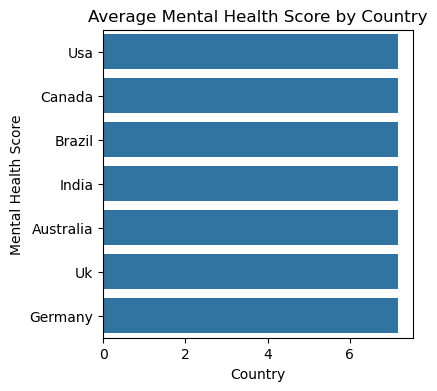

In [9]:
# Group data by countries
top_countries = (
    social_media_data.groupby("country")["mental_health_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(4, 4))
sns.barplot(x = top_countries.values, y = top_countries.index)
plt.title("Average Mental Health Score by Country")
plt.ylabel("Mental Health Score")
plt.xlabel("Country")
plt.show()

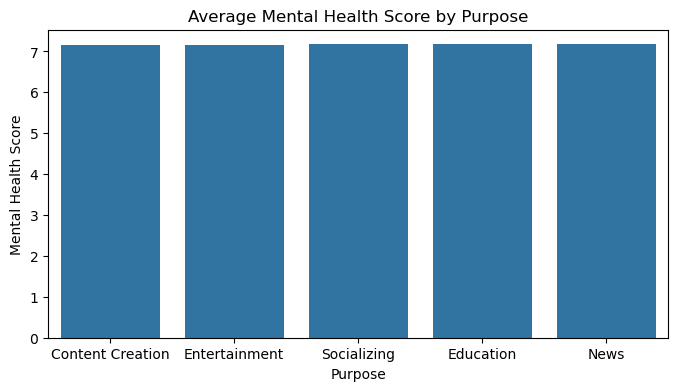

In [10]:
# Group by purpose
purpose_breakdown = social_media_data.groupby("purpose")["mental_health_score"].mean().sort_values()
plt.figure(figsize=(8, 4))
sns.barplot(x = purpose_breakdown.index, y = purpose_breakdown.values)
plt.title("Average Mental Health Score by Purpose")
plt.ylabel("Mental Health Score")
plt.xlabel("Purpose")
plt.show()

# Correlations

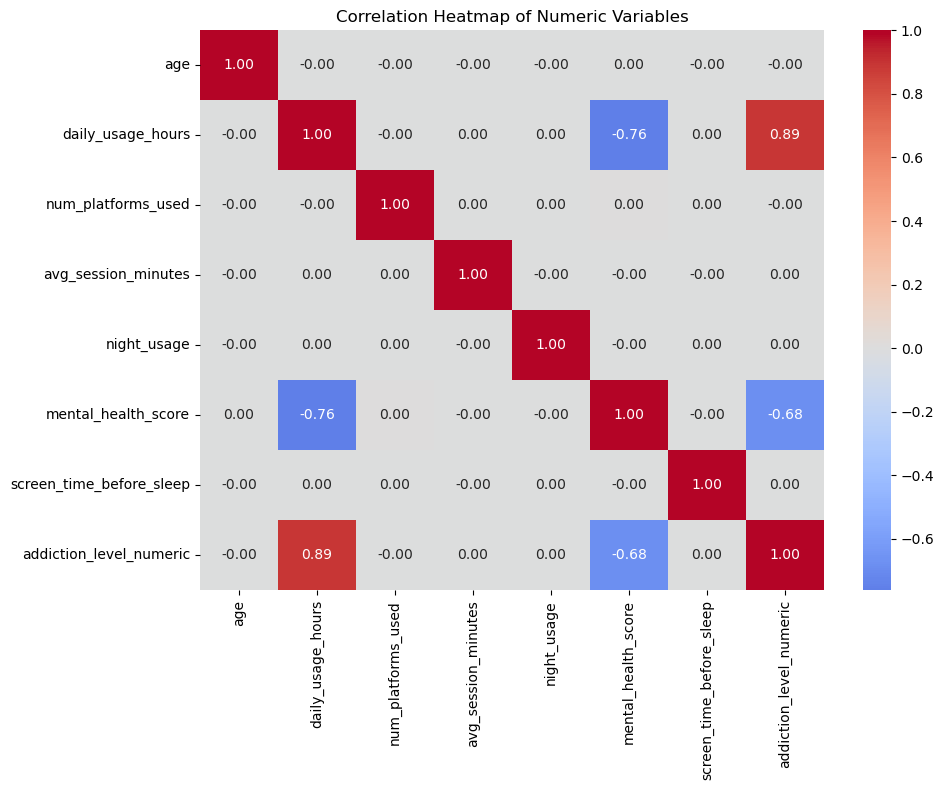

In [11]:
num_cols = social_media_data.select_dtypes(include="number")
corr_mat = num_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

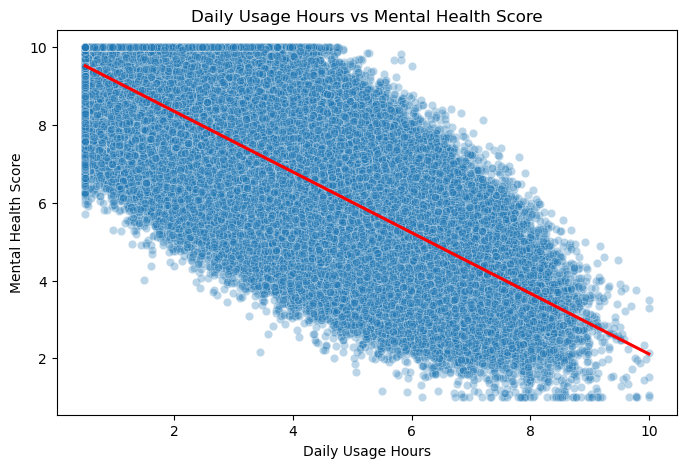

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=social_media_data, x="daily_usage_hours", y="mental_health_score", alpha=0.3)
sns.regplot(data=social_media_data, x="daily_usage_hours", y="mental_health_score", scatter=False, color="red")
plt.title("Daily Usage Hours vs Mental Health Score")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Mental Health Score")
plt.show()

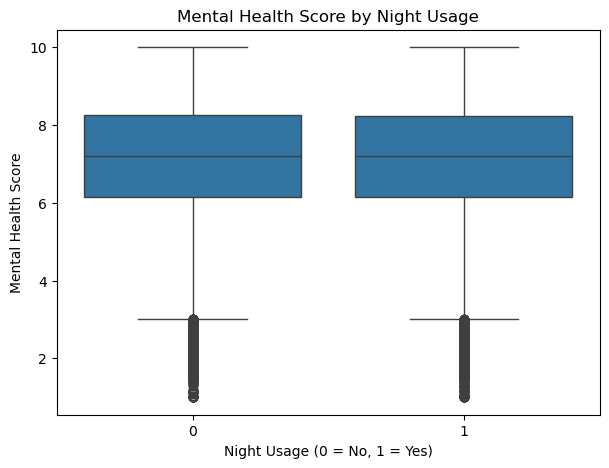

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=social_media_data, x="night_usage", y="mental_health_score")
plt.title("Mental Health Score by Night Usage")
plt.xlabel("Night Usage (0 = No, 1 = Yes)")
plt.ylabel("Mental Health Score")
plt.show()

# Observations
- Many of the average scores by country, gender, and purpose are very close to each other
- Only a few things have a drastic correlation
- Daily usage hours and mental health score are negatively correlated 
- Mental health score and addiction level are negatively correlated
- Daily usage hours and addiction level are highly correlated

This suggests that daily social media usage hours has the biggest effect on one's mental health.